# Lab 5: Practice Training Neural Networks

This notebook is designed for a 3-hour practice session on **training neural networks**. It follows the main ideas from `Training Neural Networks.pdf` and alternates between:

1. Whiteboard exercises: intuition checks and small hand calculations.
2. Coding exercises: fixing training loops, running sanity checks, and reading learning curves.
3. Diagnostic questions: choosing hyperparameters and explaining why a model behaves the way it does.

## Learning objectives

By the end of this lab, students should be able to:

1. Explain why activation functions, preprocessing, and initialization directly affect gradients.
2. Implement and read a standard PyTorch training loop: forward pass, loss, backward pass, optimizer step, and evaluation mode.
3. Use training sanity checks: initial loss, overfitting a small batch, and learning-rate checks.
4. Diagnose underfitting, overfitting, learning rates that are too high, and learning rates that are too low from loss/accuracy curves.
5. Compare regularization choices: weight decay, dropout, batch normalization, and early stopping.

## References

- Local slides: `Training Neural Networks.pdf`, Lecture 7, sections on activation functions, preprocessing, initialization, regularization, and hyperparameter babysitting.
- CS231n Assignment 2: fully-connected networks, batch normalization, dropout, PyTorch/CIFAR practice: https://cs231n.github.io/assignments2020/assignment2/
- MIT 6.390 Neural Networks notes: SGD loop, initialization, mini-batches, weight decay, dropout, batch norm: https://introml.mit.edu/notes/neural_networks.html
- MLPR Edinburgh notes: fitting and initializing neural networks, symmetry issue, scaling by input dimension: https://mlpr.inf.ed.ac.uk/2024/notes/w7c_neural_net_fitting.html
- Google ML Crash Course exercises: neural networks, overfitting and regularization practice: https://developers.google.com/machine-learning/crash-course/exercises

**Scoring:** 10 points total using checkpoints C1-C10. The detailed rubric is at the end of the notebook.


---
# Setup

This lab only uses `numpy`, `matplotlib`, and `torch`, so it should run quickly on CPU. If you are using Colab or a fresh environment, install the dependencies listed in this repository's `requirements.txt`.


In [1]:
import math
import random
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

SEED = 42
DEVICE = torch.device('cpu')


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(SEED)
print('Torch version:', torch.__version__)
print('Device:', DEVICE)


Torch version: 2.9.0
Device: cpu


## Dataset: synthetic two moons

We use a small nonlinear classification problem. The dataset is light enough for students to run several configurations during a 3-hour session, but noisy enough to show overfitting, learning-rate sensitivity, and the effect of regularization.


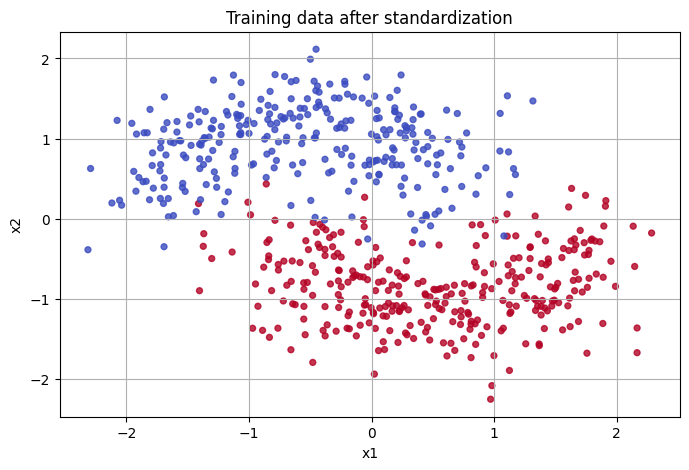

Train: torch.Size([600, 2]) Val: torch.Size([200, 2])
Class balance train: [287, 313]


In [2]:
def make_moons(n_samples=800, noise=0.35, seed=SEED):
    rng = np.random.default_rng(seed)
    n0 = n_samples // 2
    n1 = n_samples - n0

    theta0 = rng.uniform(0, math.pi, size=n0)
    x0 = np.stack([np.cos(theta0), np.sin(theta0)], axis=1)

    theta1 = rng.uniform(0, math.pi, size=n1)
    x1 = np.stack([1.0 - np.cos(theta1), -np.sin(theta1) - 0.45], axis=1)

    X = np.concatenate([x0, x1], axis=0)
    y = np.concatenate([np.zeros(n0, dtype=np.int64), np.ones(n1, dtype=np.int64)])
    X += rng.normal(0.0, noise, size=X.shape)

    order = rng.permutation(n_samples)
    return X[order].astype(np.float32), y[order]


def train_val_split(X, y, val_ratio=0.25):
    n_val = int(len(X) * val_ratio)
    X_val, y_val = X[:n_val], y[:n_val]
    X_train, y_train = X[n_val:], y[n_val:]
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True) + 1e-8
    return (X_train - mean) / std, y_train, (X_val - mean) / std, y_val


X, y = make_moons()
X_train, y_train, X_val, y_val = train_val_split(X, y)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=18, cmap='coolwarm', alpha=0.8)
plt.title('Training data after standardization')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

print('Train:', X_train_t.shape, 'Val:', X_val_t.shape)
print('Class balance train:', torch.bincount(y_train_t).tolist())


In [3]:
def make_loaders(batch_size=64, train_tensors=(X_train_t, y_train_t), val_tensors=(X_val_t, y_val_t)):
    train_ds = TensorDataset(*train_tensors)
    val_ds = TensorDataset(*val_tensors)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
    return train_loader, val_loader


def accuracy_from_logits(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()


def moving_average(values, window=5):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')


def plot_history(history, title='Training curves'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'], label='val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='train')
    axes[1].plot(history['val_acc'], label='val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].legend()
    fig.suptitle(title)
    plt.show()


def plot_decision_boundary(model, X_np=X_val, y_np=y_val, title='Decision boundary'):
    model.eval()
    x_min, x_max = X_np[:, 0].min() - 0.6, X_np[:, 0].max() + 0.6
    y_min, y_max = X_np[:, 1].min() - 0.6, X_np[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(grid), dim=1)[:, 1].cpu().numpy()
    zz = probs.reshape(xx.shape)
    plt.contourf(xx, yy, zz, levels=20, cmap='coolwarm', alpha=0.35)
    plt.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=18, cmap='coolwarm', edgecolor='k', linewidth=0.2)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()


---
# Exercise 1 - Whiteboard: activation, preprocessing, initial loss (1.0 pt)

Work on the board or on paper for 8-10 minutes.

## C1 / Exercise 1A - Activation gates and preprocessing intuition (0.5 pt)

Consider three pre-activation values: $z=-10, 0, 10$.

1. For sigmoid, what is the approximate output? Is the local gradient $\sigma(z)(1-\sigma(z))$ large or small?
2. For ReLU, what are the output and local gradient at these three points? Why can a ReLU become `dead`?
3. If every input feature is always positive, how can the gradient signs for one neuron become constrained? Why does zero-mean preprocessing reduce zig-zag optimization paths?

## C2 / Exercise 1B - Initial loss sanity check (0.5 pt)

This is a binary classification problem with cross entropy. If the untrained model predicts the two classes almost uniformly, the expected initial loss is approximately:

$$
\log(2) \approx 0.693.
$$

Answer briefly:

1. If the initial loss is around 0.69, what does that suggest?
2. If the initial loss is `nan` or extremely large, what bugs would you suspect?
3. If the initial loss is suspiciously low before training, what would you suspect?


**Answer for Exercise 1**

- 1A:
- 1B:


---
# Exercise 2 - Code: initialization and activation statistics (1.5 pts)

Goal: observe why `small random`, Xavier, and Kaiming initialization produce different activation scales in deep networks.

## C3 / Exercise 2A - Initialization implementation (1.0 pt)

Complete the function `initialize_linear_layer`.

Requirements:

1. `constant`: set every weight to `0.01`, bias to `0`.
2. `small`: Gaussian with mean `0`, std `0.01`, bias to `0`.
3. `xavier`: use Xavier/Glorot normal initialization, bias to `0`.
4. `kaiming`: use Kaiming/He normal initialization for ReLU, bias to `0`.

## C4 / Exercise 2B - Activation-statistics interpretation (0.5 pt)

After running the plots, explain what happens to activation mean/std/zero-fraction across layers and connect the behavior to the initialization choice.


In [ ]:
def activation_fn(x, name):
    if name == 'tanh':
        return torch.tanh(x)
    if name == 'relu':
        return torch.relu(x)
    if name == 'leaky_relu':
        return torch.nn.functional.leaky_relu(x, negative_slope=0.01)
    raise ValueError(f'Unknown activation: {name}')


def initialize_linear_layer(layer, mode):
    """Initialize one nn.Linear layer in-place."""
    # --- WRITE YOUR CODE HERE ---
    # Hint: use torch.no_grad(), nn.init.constant_, nn.init.normal_,
    # nn.init.xavier_normal_, nn.init.kaiming_normal_.
    raise NotImplementedError('Complete initialize_linear_layer before running this exercise.')


def make_deep_stack(width=128, depth=10, mode='xavier'):
    layers = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
    for layer in layers:
        initialize_linear_layer(layer, mode)
    return layers


def collect_activation_stats(init_mode, activation='relu', width=128, depth=10, n=512):
    set_seed(SEED)
    layers = make_deep_stack(width=width, depth=depth, mode=init_mode)
    x = torch.randn(n, width)
    stats = {'mean': [], 'std': [], 'zero_frac': []}
    with torch.no_grad():
        for layer in layers:
            x = activation_fn(layer(x), activation)
            stats['mean'].append(x.mean().item())
            stats['std'].append(x.std().item())
            stats['zero_frac'].append((x == 0).float().mean().item())
    return stats


def plot_activation_stats(stats_by_name, metric='std', title=None):
    for name, stats in stats_by_name.items():
        plt.plot(range(1, len(stats[metric]) + 1), stats[metric], marker='o', label=name)
    plt.xlabel('layer')
    plt.ylabel(metric)
    plt.title(title or f'Activation {metric} by layer')
    plt.legend()
    plt.show()


In [ ]:
# Run after completing initialize_linear_layer.
experiments_tanh = {
    mode: collect_activation_stats(mode, activation='tanh')
    for mode in ['constant', 'small', 'xavier']
}
plot_activation_stats(experiments_tanh, metric='std', title='tanh: activation std by layer')

experiments_relu = {
    mode: collect_activation_stats(mode, activation='relu')
    for mode in ['small', 'xavier', 'kaiming']
}
plot_activation_stats(experiments_relu, metric='std', title='ReLU: activation std by layer')
plot_activation_stats(experiments_relu, metric='zero_frac', title='ReLU: fraction of zeros by layer')


**Questions for Exercise 2**

1. With `constant` initialization, why do many hidden units learn the same thing?
2. With `small` initialization in a deep network, what happens to the activation standard deviation?
3. For ReLU networks, why is Kaiming initialization usually more appropriate than Xavier?

**Your answer:**

- Q1:
- Q2:
- Q3:


---
# Exercise 3 - Code: PyTorch training loop + sanity checks (2.0 pts)

Goal: complete a standard training loop and use two important sanity checks.

## C5 / Exercise 3A - Training-loop implementation (1.2 pts)

Implement the core PyTorch training step in the correct order:

```text
zero_grad -> forward -> loss -> backward -> optimizer step
```

## C6 / Exercise 3B - Sanity checks and evaluation mode (0.8 pt)

Use and explain these checks:

1. **Initial loss check:** the initial loss should be close to $\log(2)$.
2. **Overfit small batch:** a model with enough capacity should be able to overfit 64 training examples.
3. **Evaluation mode:** validation should use `model.eval()` and `torch.no_grad()`.

If the model cannot overfit the small batch, common causes include a training-loop bug, learning rate too low, bad initialization, or a model that is too small.


In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden_dims=(64, 64), dropout=0.0, batchnorm=False):
        super().__init__()
        layers = []
        in_dim = 2
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            if batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, 2))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        linear_layers = [module for module in self.net if isinstance(module, nn.Linear)]
        for i, layer in enumerate(linear_layers):
            if i == len(linear_layers) - 1:
                # Small output-layer weights keep initial logits close to zero,
                # so the initial CE loss should be near log(number_of_classes).
                nn.init.normal_(layer.weight, mean=0.0, std=0.01)
            else:
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


@dataclass
class TrainConfig:
    hidden_dims: tuple = (64, 64)
    lr: float = 1e-3
    batch_size: int = 64
    optimizer: str = 'adamw'
    weight_decay: float = 0.0
    dropout: float = 0.0
    batchnorm: bool = False


def build_optimizer(model, cfg):
    if cfg.optimizer == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=0.9, weight_decay=cfg.weight_decay)
    if cfg.optimizer == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    raise ValueError(f'Unknown optimizer: {cfg.optimizer}')


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            # --- WRITE YOUR CODE HERE ---
            # Reset old gradients before the new forward/backward pass.
            raise NotImplementedError('Add optimizer.zero_grad() here.')

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            # --- WRITE YOUR CODE HERE ---
            # Backpropagate and update parameters.
            raise NotImplementedError('Add loss.backward() and optimizer.step() here.')

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_examples += xb.size(0)

    return {
        'loss': total_loss / total_examples,
        'acc': total_correct / total_examples,
    }


def train_model(cfg, epochs=60, train_loader=None, val_loader=None, verbose=False):
    set_seed(SEED)
    model = MLP(hidden_dims=cfg.hidden_dims, dropout=cfg.dropout, batchnorm=cfg.batchnorm).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, cfg)
    if train_loader is None or val_loader is None:
        train_loader, val_loader = make_loaders(batch_size=cfg.batch_size)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_state = None
    best_val_acc = -1.0

    for epoch in range(epochs):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        with torch.no_grad():
            val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['acc'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['acc'])

        if val_metrics['acc'] > best_val_acc:
            best_val_acc = val_metrics['acc']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(
                f"epoch {epoch:03d} | "
                f"train loss {train_metrics['loss']:.3f} acc {train_metrics['acc']:.3f} | "
                f"val loss {val_metrics['loss']:.3f} acc {val_metrics['acc']:.3f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [ ]:
# Initial loss sanity check. Expected value: around log(2) = 0.693.
set_seed(SEED)
model = MLP(hidden_dims=(64, 64)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
with torch.no_grad():
    logits = model(X_train_t[:256].to(DEVICE))
    init_loss = criterion(logits, y_train_t[:256].to(DEVICE)).item()
print('Initial loss:', round(init_loss, 4), '| expected near:', round(math.log(2), 4))


In [ ]:
# Overfit a small batch. Goal: train_acc should get very close to 1.0.
small_X = X_train_t[:64]
small_y = y_train_t[:64]
small_loader = DataLoader(TensorDataset(small_X, small_y), batch_size=64, shuffle=True)

small_cfg = TrainConfig(hidden_dims=(128, 128), lr=5e-3, batch_size=64, optimizer='adamw', weight_decay=0.0)
small_model, small_history = train_model(
    small_cfg,
    epochs=180,
    train_loader=small_loader,
    val_loader=small_loader,
    verbose=False,
)
plot_history(small_history, title='Sanity check: overfit 64 training examples')
print('Final small-batch train acc:', round(small_history['train_acc'][-1], 3))


**Questions for Exercise 3**

1. If small-batch training accuracy does not get high, what are the first three things you would check?
2. In PyTorch, why should we call `model.eval()` when evaluating a model that uses dropout or batch normalization?
3. Why should we use `torch.no_grad()` during validation?

**Your answer:**

- Q1:
- Q2:
- Q3:


---
# Exercise 4 - Code + diagnosis: learning rate and optimizer (1.5 pts)

## C7 / Exercise 4 - Learning-rate/optimizer experiments and diagnosis (1.5 pts)

Run a few short configurations and inspect the learning curves. The goal is not to find the best model immediately, but to recognize common signals:

- Loss does not decrease: learning rate is too low, optimizer/config is not suitable, or there is a bug.
- Loss jumps wildly or becomes `nan`: learning rate is too high, or gradients/initialization are unstable.
- Training performance is good but validation performance is poor: overfitting.
- Both training and validation performance are poor, with a small gap: underfitting or insufficient training.

To receive full credit for C7, run at least three configurations, compare their curves, and propose two concrete follow-up experiments.


In [ ]:
def summarize_history(name, cfg, history):
    return {
        'name': name,
        'optimizer': cfg.optimizer,
        'lr': cfg.lr,
        'batch_size': cfg.batch_size,
        'weight_decay': cfg.weight_decay,
        'dropout': cfg.dropout,
        'batchnorm': cfg.batchnorm,
        'final_train_acc': history['train_acc'][-1],
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc': max(history['val_acc']),
        'final_val_loss': history['val_loss'][-1],
    }


lr_configs = {
    'sgd_too_low': TrainConfig(hidden_dims=(64, 64), optimizer='sgd', lr=1e-5, batch_size=64),
    'sgd_reasonable': TrainConfig(hidden_dims=(64, 64), optimizer='sgd', lr=5e-2, batch_size=64),
    'adamw_reasonable': TrainConfig(hidden_dims=(64, 64), optimizer='adamw', lr=1e-3, batch_size=64),
}

lr_results = []
lr_histories = {}

for name, cfg in lr_configs.items():
    print('Running', name, cfg)
    model, history = train_model(cfg, epochs=50, verbose=False)
    lr_histories[name] = history
    lr_results.append(summarize_history(name, cfg, history))

for row in lr_results:
    print(row)

for name, history in lr_histories.items():
    plot_history(history, title=name)


**Questions for Exercise 4**

1. Which configuration learns the slowest? What is the signal in the curve?
2. Which configuration is worth refining further? Why?
3. If you could run only 2 more experiments, what `lr`, `optimizer`, and `batch_size` would you choose?

**Your answer:**

- Q1:
- Q2:
- Q3:


---
# Exercise 5 - Code: regularization and coarse hyperparameter search (2.0 pts)

## C8 / Exercise 5A - Regularization search setup and results table (1.0 pt)

Create at least 4 configurations to compare. You must include:

1. A baseline configuration with no regularization.
2. A configuration with weight decay.
3. A configuration with dropout.
4. A configuration with batch normalization, or batch normalization combined with weight decay.

For each configuration, record `best_val_acc`, `final_train_acc`, and `final_val_acc`.

## C9 / Exercise 5B - Model selection and regularization explanation (1.0 pt)

Choose the final model based on the validation set, not the test set. Explain whether the best validation model is also the highest-training-accuracy model, and describe how the regularizers affected the train-validation gap.


In [ ]:
# --- WRITE YOUR CODE HERE ---
# Edit this dictionary. Add at least 4 named configs.
search_configs = {
    'baseline_adamw': TrainConfig(hidden_dims=(64, 64), optimizer='adamw', lr=1e-3, batch_size=64),
    # 'weight_decay': TrainConfig(...),
    # 'dropout': TrainConfig(...),
    # 'batchnorm': TrainConfig(...),
}

search_results = []
search_histories = {}
search_models = {}

for name, cfg in search_configs.items():
    print('Running', name, cfg)
    model, history = train_model(cfg, epochs=80, verbose=False)
    search_models[name] = model
    search_histories[name] = history
    search_results.append(summarize_history(name, cfg, history))

# Sort by best validation accuracy.
search_results = sorted(search_results, key=lambda row: row['best_val_acc'], reverse=True)
for row in search_results:
    print(row)

best_name = search_results[0]['name']
best_model = search_models[best_name]
print('Best config:', best_name)
plot_history(search_histories[best_name], title=f'Best config: {best_name}')
plot_decision_boundary(best_model, title=f'Decision boundary: {best_name}')


**Questions for Exercise 5**

1. What is your best validation configuration? Is it also the configuration with the highest training accuracy?
2. How do weight decay, dropout, and batch normalization affect the train-validation gap?
3. If validation accuracy is still increasing at the final epoch, what would you do next?

**Your answer:**

- Q1:
- Q2:
- Q3:


---
# Exercise 6 - Whiteboard: read learning curves and propose next steps (2.0 pts)

## C10 / Exercise 6 - Learning-curve diagnosis and next experiments (2.0 pts)

For each case, write a diagnosis and the next experiment you would run.

| Case | Observation | Diagnosis | Next experiment |
|---|---|---|---|
| A | Train accuracy increases steadily, and validation accuracy is still increasing at the final epoch | ? | ? |
| B | Train accuracy is 99%, validation accuracy is 72%, train-validation gap is large | ? | ? |
| C | Train accuracy is 62%, validation accuracy is 61%, loss decreases very slowly | ? | ? |
| D | Loss becomes `nan` after a few iterations | ? | ? |
| E | Initial loss is suspiciously low before training | ? | ? |

**Your answer:**

- A:
- B:
- C:
- D:
- E:


---
# Optional add-on: professional ML tooling

This section is **not part of the 10-point core grade**. Use it if the class finishes early, or as a short preview of tools students will see in real ML projects.

## Tools to know

| Tool/product | What students should remember |
|---|---|
| Weights & Biases (`wandb`) | Track experiments: configs, metrics, curves, tables, artifacts, and comparisons across runs. |
| JAX | A NumPy-like system for composable program transformations such as automatic differentiation, JIT compilation, and vectorization. |
| Hugging Face Hub | Discover, share, and reuse models, datasets, and demos. |
| Vast.ai | Rent GPU instances from a marketplace when local/Colab compute is not enough. |

Suggested framing for students: **do not try to master all tools today**. The goal is to know what problem each tool solves.

If the optional packages are missing, install them outside this notebook or uncomment the line below in a fresh environment:

```bash
pip install wandb jax
```

Official docs:

- W&B experiment tracking: https://docs.wandb.ai/models/track/create-an-experiment
- JAX quickstart: https://docs.jax.dev/en/latest/quickstart.html
- Hugging Face Hub docs: https://huggingface.co/docs/hub
- Vast.ai instances overview: https://docs.vast.ai/guides/instances/overview
- Vast.ai quickstart: https://docs.vast.ai/quickstart


In [ ]:
# Optional: log an existing training history to Weights & Biases.
# This cell is safe to run even when wandb is not installed.

try:
    import wandb
    from dataclasses import asdict, is_dataclass
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False


def config_to_dict(cfg):
    if is_dataclass(cfg):
        return asdict(cfg)
    if hasattr(cfg, '__dict__'):
        return dict(cfg.__dict__)
    return dict(cfg)


def log_history_to_wandb(run_name, cfg, history, project='training-nn-practice', mode='offline'):
    """Log a completed history dictionary to W&B.

    Use mode='offline' for classroom demos without requiring login.
    After logging in later, offline runs can be synced from the terminal.
    """
    if not WANDB_AVAILABLE:
        print('wandb is not installed. Install with: pip install wandb')
        return None

    run = wandb.init(
        project=project,
        name=run_name,
        config=config_to_dict(cfg),
        mode=mode,
    )
    for epoch in range(len(history['train_loss'])):
        wandb.log({
            'epoch': epoch,
            'train/loss': history['train_loss'][epoch],
            'train/accuracy': history['train_acc'][epoch],
            'val/loss': history['val_loss'][epoch],
            'val/accuracy': history['val_acc'][epoch],
        }, step=epoch)
    run.finish()
    print(f'Logged run to W&B in {mode!r} mode:', run_name)
    return run


# Example usage after Exercise 5 has been run:
if 'search_histories' in globals() and search_histories:
    best_name_for_logging = max(search_histories, key=lambda name: max(search_histories[name]['val_acc']))
    log_history_to_wandb(
        best_name_for_logging,
        search_configs[best_name_for_logging],
        search_histories[best_name_for_logging],
    )
else:
    print('Run Exercise 5 first, then rerun this cell to log the best history to W&B.')


In [ ]:
# Optional: JAX mini-demo.
# This shows the same idea as a training step, but in a functional style.

try:
    import jax
    import jax.numpy as jnp
    JAX_AVAILABLE = True
except ImportError:
    JAX_AVAILABLE = False

if not JAX_AVAILABLE:
    print('jax is not installed. Install with: pip install jax')
else:
    Xb = jnp.asarray(X_train[:256], dtype=jnp.float32)
    yb = jnp.asarray(y_train[:256], dtype=jnp.float32)

    def logistic_loss(params, X_batch, y_batch):
        w, b = params
        logits = X_batch @ w + b
        # Stable binary cross entropy with logits:
        return jnp.mean(jnp.logaddexp(0.0, logits) - y_batch * logits)

    @jax.jit
    def gradient_step(params, X_batch, y_batch, lr=0.1):
        loss, grads = jax.value_and_grad(logistic_loss)(params, X_batch, y_batch)
        new_params = (
            params[0] - lr * grads[0],
            params[1] - lr * grads[1],
        )
        return new_params, loss

    params = (jnp.zeros((2,), dtype=jnp.float32), jnp.array(0.0, dtype=jnp.float32))
    losses = []
    for _ in range(200):
        params, loss = gradient_step(params, Xb, yb, lr=0.2)
        losses.append(float(loss))

    logits = Xb @ params[0] + params[1]
    preds = (jax.nn.sigmoid(logits) >= 0.5).astype(jnp.int32)
    acc = float(jnp.mean(preds == yb))

    plt.plot(losses)
    plt.title('JAX logistic regression demo: loss over steps')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.show()

    print('Final JAX demo accuracy on 256 examples:', round(acc, 3))
    print('Learned parameters:', params)


## Optional: Hugging Face and Vast.ai workflow map

No account or payment is required for this lab section. This is a conceptual workflow so students understand where pretrained resources and remote GPU compute fit into a project.

## Hugging Face Hub

Use Hugging Face when you need to:

1. Find a pretrained model instead of training from scratch.
2. Find a dataset and inspect its documentation/card.
3. Share a model checkpoint or demo with other people.
4. Build a small public demo with Spaces.

Good habits:

- Read model cards and dataset cards before using anything.
- Check license, intended use, limitations, and evaluation results.
- Record the exact model/dataset version in your experiment notes.

## Vast.ai GPU rental checklist

Vast.ai instances are containerized GPU environments. The practical idea is: choose a template/container environment, rent a GPU instance, connect through Jupyter or SSH, run your experiment, save your outputs, then stop or delete the instance.

Before renting:

1. Estimate the required GPU memory: small MLP/CNN practice may not need a paid GPU; larger vision/LLM workloads might.
2. Choose a template such as a PyTorch or CUDA image that already has the right framework.
3. Compare offers by GPU model, VRAM, price, reliability, disk size, upload/download bandwidth, and location.
4. Decide whether an interruptible/cheaper instance is acceptable. For fragile long jobs, prefer a more stable option.
5. Avoid putting private keys, API tokens, or private datasets into throwaway notebooks.

While running:

1. Use Jupyter for notebooks or SSH for terminal workflows.
2. Immediately run `nvidia-smi` to confirm the GPU is visible.
3. Save important outputs to a durable place, such as local download, cloud storage, or a model hub.
4. Track cost while the instance is running.

When finished:

1. Stop the instance if you may resume later, but remember storage may still cost money.
2. Delete the instance when you are done and have saved everything you need.
3. Never assume a rented instance is permanent storage.


## Optional reflection questions

1. What is the difference between a notebook full of plots and an experiment tracker such as W&B?
2. In the JAX demo, why are parameters passed into a function instead of stored inside a mutable model object?
3. Compare PyTorch and JAX at a high level: what feels similar, and what feels different?
4. When would you look for a pretrained model or dataset on Hugging Face instead of building everything from scratch?
5. Before renting a GPU on Vast.ai, what would you check to avoid wasting money?
6. Which tool would you use for each task?
   - Compare 20 training runs.
   - Share a pretrained model or dataset.
   - Run a training job that is too slow on your laptop.
   - Reproduce an experiment later with the exact same settings.


---
# Submission checklist

Before submitting or demoing to the TA, check that:

- C1-C2: Exercise 1 has short but clear answers about activation gates, preprocessing, and initial loss.
- C3-C4: Exercise 2 runs activation-statistics plots for both `tanh` and `relu`, and includes interpretation.
- C5-C6: Exercise 3 has a correct training loop, uses validation mode correctly, and can overfit a small batch.
- C7: Exercise 4 includes at least 3 learning-rate/optimizer curves and analysis.
- C8-C9: Exercise 5 includes at least 4 regularization/search configurations, a results table, and a validation-based model choice.
- C10: Exercise 6 includes a diagnosis and a next experiment for all 5 cases.
